<a href="https://colab.research.google.com/github/Arfwjn/Speech-to-Text/blob/main/STT_WhisperONNX_VAD_repaired_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimasi Pipeline ASR untuk Komputasi CPU Rendah-Sumber Daya
Notebook ini disusun ulang agar mengikuti pipeline penelitian 12 minggu untuk sistem ASR *offline-first* berbasis **Silero VAD + Distil-Whisper-Small ONNX INT8** pada CPU tanpa CUDA.

## Tujuan Notebook
1. Menyiapkan environment CPU-friendly
2. Menyiapkan dataset evaluasi dan preprocessing audio
3. Mengintegrasikan Silero VAD untuk trimming keheningan
4. Mengekspor model `distil-small.en` ke ONNX
5. Melakukan kuantisasi dinamis INT8
6. Menjalankan benchmark akurasi dan performa pada CPU
7. Menyediakan hook integrasi ke AIRA dan Gemini API


## Fase 1 - Setup Environment, Dataset, dan Preprocessing
Bagian ini menggantikan workflow fine-tuning LoRA/GPU pada notebook lama, karena target penelitian adalah **inferensi CPU rendah-sumber daya**, bukan training model.


In [7]:
# Sel 1: Instalasi dependensi inti CPU-friendly untuk pipeline penelitian
# Jalankan sekali saja bila environment belum lengkap.
# Paket dibagi agar lebih mudah debug jika ada library yang gagal.
%pip install -q transformers optimum[onnxruntime] datasets evaluate jiwer librosa soundfile pandas matplotlib seaborn psutil tqdm huggingface_hub accelerate --upgrade --quiet
%pip install -q onnx onnxruntime onnxruntime-tools --quiet
%pip install -q silero-vad openai-whisper --quiet

print('Dependensi inti untuk riset ASR CPU siap atau sudah terpasang.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 44.4 MB/s eta 0:00:00
Dependensi inti untuk riset ASR CPU siap atau sudah terpasang.


In [1]:
# Sel 2: Import library, konfigurasi global, dan spesifikasi target hardware penelitian
import os
import gc
import re
import time
import json
import math
import psutil
import shutil
import platform
import warnings
import subprocess
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from pathlib import Path
from tqdm.auto import tqdm
from datasets import load_dataset, Audio
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq, pipeline
from optimum.onnxruntime import ORTModelForSpeechSeq2Seq
import evaluate
import jiwer

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd()
ARTIFACT_DIR = PROJECT_ROOT / 'asr_cpu_artifacts'
AUDIO_DIR = ARTIFACT_DIR / 'audio_samples'
MODEL_DIR = ARTIFACT_DIR / 'models'
RESULT_DIR = ARTIFACT_DIR / 'results'

for target_dir in [ARTIFACT_DIR, AUDIO_DIR, MODEL_DIR, RESULT_DIR]:
    target_dir.mkdir(parents=True, exist_ok=True)

MODEL_ID = 'distil-whisper/distil-small.en'
SAMPLE_RATE = 16000
FAST_EVAL_SAMPLES = 20
FINAL_EVAL_SAMPLES = 50
MAX_AUDIO_SECONDS = 30
LANGUAGE = 'english'
TASK = 'transcribe'
DEVICE = 'cpu'
CPU_PROVIDER = 'CPUExecutionProvider'

TARGET_HARDWARE = {
    'processor': 'AMD Ryzen 5 5500U',
    'cores_threads': '6 cores / 12 threads',
    'ram': '16 GB DDR4',
    'graphics': 'Integrated AMD Radeon Graphics',
    'storage_free': '≈ 165 GB',
    'instruction_set': 'AVX2 enabled'
}

runtime_info = {
    'detected_processor': platform.processor(),
    'machine': platform.machine(),
    'platform': platform.platform(),
    'python': platform.python_version(),
    'torch_version': torch.__version__,
    'physical_cores': psutil.cpu_count(logical=False),
    'logical_cores': psutil.cpu_count(logical=True),
    'ram_gb_detected': round(psutil.virtual_memory().total / (1024 ** 3), 2)
}

print(pd.DataFrame([TARGET_HARDWARE]))
print(pd.DataFrame([runtime_info]))


Multiple distributions found for package optimum. Picked distribution: optimum
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


           processor         cores_threads         ram  \
0  AMD Ryzen 5 5500U  6 cores / 12 threads  16 GB DDR4   

                         graphics storage_free instruction_set  
0  Integrated AMD Radeon Graphics     ≈ 165 GB    AVX2 enabled  
  detected_processor machine                              platform   python  \
0             x86_64  x86_64  Linux-6.6.122+-x86_64-with-glibc2.35  3.12.13   

  torch_version  physical_cores  logical_cores  ram_gb_detected  
0    2.10.0+cpu               1              2            12.67  


In [2]:
# Sel 3: Definisikan target eksperimen dan metrik penelitian
TARGETS_DF = pd.DataFrame([
    {'metric': 'WER drift vs baseline FP32', 'target': '<= 4 percentage points'},
    {'metric': 'Real-Time Factor', 'target': '<= 0.3'},
    {'metric': 'Model file size', 'target': '< 200 MB'},
    {'metric': 'Runtime RAM aktif', 'target': '< 1 GB'}
])
print(TARGETS_DF)


                       metric                  target
0  WER drift vs baseline FP32  <= 4 percentage points
1            Real-Time Factor                  <= 0.3
2             Model file size                < 200 MB
3           Runtime RAM aktif                  < 1 GB


In [3]:
# Sel 4: Muat dataset evaluasi dan siapkan dua mode benchmark
wer_metric = evaluate.load('wer')
raw_eval_all = load_dataset('librispeech_asr', 'clean', split='validation')
raw_eval_all = raw_eval_all.cast_column('audio', Audio(sampling_rate=SAMPLE_RATE))

raw_eval_fast = raw_eval_all.select(range(FAST_EVAL_SAMPLES))
raw_eval_final = raw_eval_all.select(range(FINAL_EVAL_SAMPLES))
raw_eval_ds = raw_eval_fast

print('Fast benchmark samples:', len(raw_eval_fast))
print('Final benchmark samples:', len(raw_eval_final))
print(raw_eval_ds[0])


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

clean/test/0000.parquet:   0%|          | 0.00/350M [00:00<?, ?B/s]

clean/train.100/0000.parquet:   0%|          | 0.00/470M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/2620 [00:00<?, ? examples/s]

Generating train.100 split:   0%|          | 0/28539 [00:00<?, ? examples/s]

Generating train.360 split:   0%|          | 0/104014 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2703 [00:00<?, ? examples/s]

Fast benchmark samples: 20
Final benchmark samples: 50
{'file': '/home/albert/.cache/huggingface/datasets/downloads/extracted/234bf103726646f6948bab918be3a226316832f62b2ca6861100cff043922b4a/2277-149896-0000.flac', 'audio': <datasets.features._torchcodec.AudioDecoder object at 0x7da1d01d6c60>, 'text': "HE WAS IN A FEVERED STATE OF MIND OWING TO THE BLIGHT HIS WIFE'S ACTION THREATENED TO CAST UPON HIS ENTIRE FUTURE", 'speaker_id': 2277, 'chapter_id': 149896, 'id': '2277-149896-0000'}


  0%|          | 0/20 [00:00<?, ?it/s]

   sample_id  speaker_id  chapter_id  \
0          0        2277      149896   
1          1        2277      149896   
2          2        2277      149896   
3          3        2277      149896   
4          4        2277      149896   

                                                text  audio_seconds  
0  HE WAS IN A FEVERED STATE OF MIND OWING TO THE...          6.590  
1  HE WOULD HAVE TO PAY HER THE MONEY WHICH SHE W...          7.145  
2  HURSTWOOD WALKED THE FLOOR MENTALLY ARRANGING ...          4.835  
3         HE ALSO THOUGHT OF HIS MANAGERIAL POSITION          2.840  
4                 HOW WOULD THE PAPERS TALK ABOUT IT          1.955  


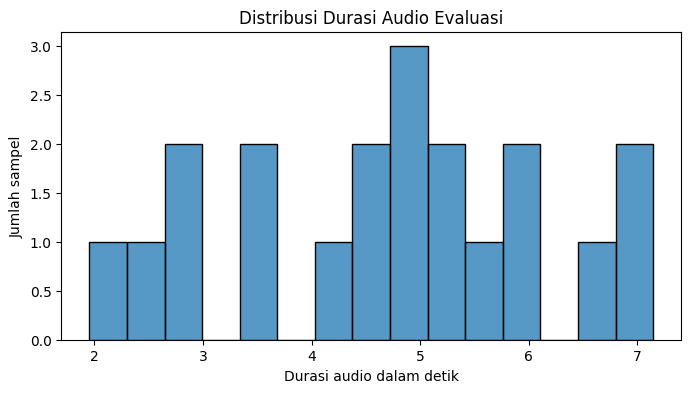

In [4]:
# Sel 5: Ubah dataset menjadi tabel metadata evaluasi
sample_rows = []
for row_idx in tqdm(range(len(raw_eval_ds))):
    item_obj = raw_eval_ds[row_idx]
    audio_info = item_obj['audio']
    audio_seconds = len(audio_info['array']) / audio_info['sampling_rate']
    sample_rows.append({
        'sample_id': row_idx,
        'speaker_id': item_obj.get('speaker_id', None),
        'chapter_id': item_obj.get('chapter_id', None),
        'text': item_obj['text'],
        'audio_seconds': audio_seconds
    })

eval_df = pd.DataFrame(sample_rows)
print(eval_df.head())

plt.figure(figsize=(8, 4))
sns.histplot(eval_df['audio_seconds'], bins=15, color='#1f77b4')
plt.title('Distribusi Durasi Audio Evaluasi')
plt.xlabel('Durasi audio dalam detik')
plt.ylabel('Jumlah sampel')
plt.show()


## Fase 2 - Integrasi Silero VAD, Ekspor ONNX, dan Kuantisasi INT8
Bagian ini menggantikan blok notebook lama yang berisi LoRA, PEFT, training, dan merge model. Fokus penelitian diarahkan ke **optimasi inferensi CPU**.


In [5]:
# Sel 6: Processor dan normalisasi teks yang konsisten untuk semua pipeline
processor = AutoProcessor.from_pretrained(MODEL_ID)
text_normalizer = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemoveMultipleSpaces(),
    jiwer.Strip(),
    jiwer.RemovePunctuation()
])

def normalize_text(text_value):
    if text_value is None:
        return ''
    return text_normalizer(text_value)

print('Processor siap untuk model ' + MODEL_ID)


preprocessor_config.json:   0%|          | 0.00/339 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Processor siap untuk model distil-whisper/distil-small.en


In [6]:
# Sel 7: Helper benchmark, memory monitor, CPU sampling, dan utilitas file
process_obj = psutil.Process(os.getpid())

def get_memory_mb():
    return process_obj.memory_info().rss / (1024 ** 2)

def get_cpu_percent(sample_seconds=0.15):
    return psutil.cpu_percent(interval=sample_seconds)

def compute_rtf(inference_seconds, audio_seconds):
    if audio_seconds <= 0:
        return np.nan
    return inference_seconds / audio_seconds

def get_dir_size_mb(folder_path):
    folder_obj = Path(folder_path)
    if not folder_obj.exists():
        return np.nan
    total_bytes = 0
    for path_obj in folder_obj.rglob('*'):
        if path_obj.is_file():
            total_bytes += path_obj.stat().st_size
    return total_bytes / (1024 ** 2)

def save_wav_file(audio_array, sample_rate, file_path):
    sf.write(file_path, np.asarray(audio_array, dtype=np.float32), sample_rate)
    return str(file_path)


In [7]:
# Sel 8: Integrasi Silero VAD yang lebih robust untuk trimming keheningan pada CPU
try:
    from silero_vad import load_silero_vad, get_speech_timestamps
    vad_model = load_silero_vad()
    silero_ready = True
except Exception as exc_obj:
    vad_model = None
    silero_ready = False
    print('Silero VAD belum aktif: ' + str(exc_obj))

def apply_silero_vad(audio_array, sample_rate=SAMPLE_RATE, min_silence_ms=250, min_kept_seconds=0.3):
    audio_float32 = np.asarray(audio_array, dtype=np.float32)
    if len(audio_float32) == 0:
        return audio_float32, {'speech_ratio': 0.0, 'num_segments': 0, 'trimmed': False, 'fallback_used': True}
    if not silero_ready:
        return audio_float32, {'speech_ratio': 1.0, 'num_segments': 1, 'trimmed': False, 'fallback_used': True}
    speech_segments = get_speech_timestamps(
        audio_float32,
        vad_model,
        sampling_rate=sample_rate,
        min_silence_duration_ms=min_silence_ms
    )
    if len(speech_segments) == 0:
        return audio_float32, {'speech_ratio': 1.0, 'num_segments': 0, 'trimmed': False, 'fallback_used': True}
    merged_chunks = [audio_float32[seg['start']:seg['end']] for seg in speech_segments if seg['end'] > seg['start']]
    if len(merged_chunks) == 0:
        return audio_float32, {'speech_ratio': 1.0, 'num_segments': 0, 'trimmed': False, 'fallback_used': True}
    merged_audio = np.concatenate(merged_chunks)
    min_kept_samples = int(sample_rate * min_kept_seconds)
    if len(merged_audio) < min_kept_samples:
        return audio_float32, {'speech_ratio': 1.0, 'num_segments': len(speech_segments), 'trimmed': False, 'fallback_used': True}
    speech_ratio = len(merged_audio) / max(len(audio_float32), 1)
    return merged_audio, {'speech_ratio': speech_ratio, 'num_segments': len(speech_segments), 'trimmed': speech_ratio < 0.999, 'fallback_used': False}

print('Silero ready:', silero_ready)


Silero ready: True


In [11]:
# Sel 9: Baseline pipeline FP32 CPU sebagai pembanding yang fair
baseline_model = AutoModelForSpeechSeq2Seq.from_pretrained(MODEL_ID)
baseline_pipe = pipeline(
    task='automatic-speech-recognition',
    model=baseline_model,
    tokenizer=processor.tokenizer,
    feature_extractor=processor.feature_extractor,
    device=-1,
    chunk_length_s=MAX_AUDIO_SECONDS
)

# BASELINE_GENERATE_KWARGS = {
#     'language': LANGUAGE, # Removed for English-only model
#     'task': TASK # Removed for English-only model
# }

print('Baseline FP32 CPU pipeline siap untuk benchmark.')

Device set to use cpu
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


Baseline FP32 CPU pipeline siap untuk benchmark.


In [12]:
# Sel 10: Benchmark baseline FP32 pada mode cepat
baseline_rows = []
for row_idx in tqdm(range(len(raw_eval_ds))):
    item_obj = raw_eval_ds[row_idx]
    audio_array = np.asarray(item_obj['audio']['array'], dtype=np.float32)
    audio_seconds = len(audio_array) / SAMPLE_RATE
    mem_before = get_memory_mb()
    cpu_before = get_cpu_percent(0.05)
    start_time = time.perf_counter()
    pred_obj = baseline_pipe(audio_array, generate_kwargs=BASELINE_GENERATE_KWARGS)
    infer_seconds = time.perf_counter() - start_time
    cpu_after = get_cpu_percent(0.05)
    mem_after = get_memory_mb()
    baseline_rows.append({
        'sample_id': row_idx,
        'reference': normalize_text(item_obj['text']),
        'prediction': normalize_text(pred_obj['text']),
        'audio_seconds': audio_seconds,
        'inference_seconds': infer_seconds,
        'rtf': compute_rtf(infer_seconds, audio_seconds),
        'rss_before_mb': mem_before,
        'rss_after_mb': mem_after,
        'rss_delta_mb': mem_after - mem_before,
        'cpu_before_pct': cpu_before,
        'cpu_after_pct': cpu_after,
        'pipeline_name': 'baseline_fp32_cpu'
    })

baseline_result_df = pd.DataFrame(baseline_rows)
print(baseline_result_df.head())


  0%|          | 0/20 [00:00<?, ?it/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.


   sample_id                                          reference  \
0          0  he was in a fevered state of mind owing to the...   
1          1  he would have to pay her the money which she w...   
2          2  hurstwood walked the floor mentally arranging ...   
3          3         he also thought of his managerial position   
4          4                 how would the papers talk about it   

                                          prediction  audio_seconds  \
0  he was in a fevered state of mind owing to the...          6.590   
1  he would have to pay her the money which he wo...          7.145   
2  hurstwood walked the floor mentally arranging ...          4.835   
3         he also thought of his managerial position          2.840   
4                 how would the papers talk about it          1.955   

   inference_seconds       rtf  rss_before_mb  rss_after_mb  rss_delta_mb  \
0          25.213775  3.826066    4325.191406   4530.542969    205.351562   
1          32.36

In [13]:
# Sel 11: Ringkasan baseline FP32 beserta ukuran model acuan
baseline_wer = wer_metric.compute(
    references=baseline_result_df['reference'].tolist(),
    predictions=baseline_result_df['prediction'].tolist()
)

baseline_model_size_mb = np.nan
try:
    baseline_model_size_mb = get_dir_size_mb(processor.feature_extractor._processor_class)
except Exception:
    baseline_model_size_mb = np.nan

baseline_summary_df = pd.DataFrame([{
    'pipeline_name': 'baseline_fp32_cpu',
    'wer': baseline_wer,
    'mean_rtf': baseline_result_df['rtf'].mean(),
    'median_rtf': baseline_result_df['rtf'].median(),
    'peak_rss_delta_mb': baseline_result_df['rss_delta_mb'].max(),
    'mean_cpu_after_pct': baseline_result_df['cpu_after_pct'].mean(),
    'model_size_mb': baseline_model_size_mb
}])
print(baseline_summary_df)


       pipeline_name       wer  mean_rtf  median_rtf  peak_rss_delta_mb  \
0  baseline_fp32_cpu  0.034268   2.93179    2.664859         205.351562   

   mean_cpu_after_pct  model_size_mb  
0               13.46            NaN  


In [14]:
# Sel 12: Validasi environment ONNX dan siapkan command export yang lebih aman
ONNX_EXPORT_DIR = MODEL_DIR / 'distil_small_en_onnx'
ONNX_INT8_DIR = MODEL_DIR / 'distil_small_en_onnx_int8'

try:
    import optimum
    import onnxruntime
    onnx_env_ready = True
except Exception as exc_obj:
    onnx_env_ready = False
    print('Environment ONNX belum siap: ' + str(exc_obj))

export_command = [
    'optimum-cli', 'export', 'onnx',
    '--model', MODEL_ID,
    '--task', 'automatic-speech-recognition',
    str(ONNX_EXPORT_DIR)
]

print('ONNX environment ready:', onnx_env_ready)
print('Perintah export ONNX:')
print(' '.join(export_command))

if onnx_env_ready:
    print('Anda bisa jalankan subprocess command ini setelah dependensi terpasang.')
else:
    print('Pasang optimum dan onnxruntime terlebih dahulu sebelum export.')


ONNX environment ready: True
Perintah export ONNX:
optimum-cli export onnx --model distil-whisper/distil-small.en --task automatic-speech-recognition /content/asr_cpu_artifacts/models/distil_small_en_onnx
Anda bisa jalankan subprocess command ini setelah dependensi terpasang.


In [15]:
# Sel 13: Fungsi eksekusi export dan quantization ONNX secara opsional
quant_command = [
    'optimum-cli', 'onnxruntime', 'quantize',
    '--onnx_model', str(ONNX_EXPORT_DIR),
    '--avx2',
    '--per_channel',
    str(ONNX_INT8_DIR)
]

RUN_ONNX_COMMANDS = False

print('Perintah quantization INT8:')
print(' '.join(quant_command))

if RUN_ONNX_COMMANDS:
    if not onnx_env_ready:
        raise RuntimeError('Environment ONNX belum siap.')
    export_result = subprocess.run(export_command, capture_output=True, text=True)
    print(export_result.stdout)
    print(export_result.stderr)
    if export_result.returncode != 0:
        raise RuntimeError('Export ONNX gagal.')
    quant_result = subprocess.run(quant_command, capture_output=True, text=True)
    print(quant_result.stdout)
    print(quant_result.stderr)
    if quant_result.returncode != 0:
        raise RuntimeError('Quantization ONNX gagal.')


Perintah quantization INT8:
optimum-cli onnxruntime quantize --onnx_model /content/asr_cpu_artifacts/models/distil_small_en_onnx --avx2 --per_channel /content/asr_cpu_artifacts/models/distil_small_en_onnx_int8


In [16]:
# Sel 14: Muat model ONNX INT8 dengan fallback processor yang aman
onnx_ready = ONNX_INT8_DIR.exists()
if onnx_ready:
    processor_source = str(ONNX_EXPORT_DIR) if (ONNX_EXPORT_DIR / 'preprocessor_config.json').exists() else MODEL_ID
    ort_model = ORTModelForSpeechSeq2Seq.from_pretrained(str(ONNX_INT8_DIR), provider=CPU_PROVIDER)
    onnx_processor = AutoProcessor.from_pretrained(processor_source)
    onnx_pipe = pipeline(
        task='automatic-speech-recognition',
        model=ort_model,
        tokenizer=onnx_processor.tokenizer,
        feature_extractor=onnx_processor.feature_extractor,
        device=-1,
        chunk_length_s=MAX_AUDIO_SECONDS
    )
    ONNX_GENERATE_KWARGS = {'language': LANGUAGE, 'task': TASK}
    print('Pipeline ONNX INT8 siap.')
else:
    ort_model = None
    onnx_processor = None
    onnx_pipe = None
    ONNX_GENERATE_KWARGS = {'language': LANGUAGE, 'task': TASK}
    print('Folder ONNX INT8 belum tersedia. Jalankan Sel 12-13 setelah dependensi ONNX siap.')


Folder ONNX INT8 belum tersedia. Jalankan Sel 12-13 setelah dependensi ONNX siap.


## Fase 3 - Benchmarking WER, RTF, CPU RAM, Integrasi AIRA dan Gemini API


In [17]:
# Sel 15: Benchmark ONNX INT8 dengan dan tanpa Silero VAD
benchmark_rows = []
if onnx_pipe is not None:
    for row_idx in tqdm(range(len(raw_eval_ds))):
        item_obj = raw_eval_ds[row_idx]
        source_audio = np.asarray(item_obj['audio']['array'], dtype=np.float32)
        source_seconds = len(source_audio) / SAMPLE_RATE
        for use_vad in [False, True]:
            processed_audio = source_audio.copy()
            vad_meta = {'speech_ratio': 1.0, 'num_segments': 1, 'trimmed': False, 'fallback_used': False}
            if use_vad:
                processed_audio, vad_meta = apply_silero_vad(processed_audio, SAMPLE_RATE)
            if len(processed_audio) == 0:
                processed_audio = source_audio.copy()
                vad_meta['fallback_used'] = True
            mem_before = get_memory_mb()
            cpu_before = get_cpu_percent(0.05)
            start_time = time.perf_counter()
            pred_obj = onnx_pipe(processed_audio, generate_kwargs=ONNX_GENERATE_KWARGS)
            infer_seconds = time.perf_counter() - start_time
            cpu_after = get_cpu_percent(0.05)
            mem_after = get_memory_mb()
            benchmark_rows.append({
                'sample_id': row_idx,
                'pipeline_name': 'onnx_int8_vad' if use_vad else 'onnx_int8_no_vad',
                'reference': normalize_text(item_obj['text']),
                'prediction': normalize_text(pred_obj['text']),
                'audio_seconds_original': source_seconds,
                'audio_seconds_processed': len(processed_audio) / SAMPLE_RATE,
                'speech_ratio': vad_meta['speech_ratio'],
                'num_segments': vad_meta['num_segments'],
                'vad_trimmed': vad_meta['trimmed'],
                'vad_fallback_used': vad_meta['fallback_used'],
                'inference_seconds': infer_seconds,
                'rtf': compute_rtf(infer_seconds, source_seconds),
                'rss_before_mb': mem_before,
                'rss_after_mb': mem_after,
                'rss_delta_mb': mem_after - mem_before,
                'cpu_before_pct': cpu_before,
                'cpu_after_pct': cpu_after
            })
benchmark_result_df = pd.DataFrame(benchmark_rows)
print(benchmark_result_df.head())


Empty DataFrame
Columns: []
Index: []


In [18]:
# Sel 16: Ringkasan benchmarking lengkap dengan delta WER dan speedup terhadap baseline
summary_rows = baseline_summary_df.to_dict(orient='records')
if len(benchmark_rows) > 0:
    for pipeline_name, part_df in benchmark_result_df.groupby('pipeline_name'):
        pipeline_wer = wer_metric.compute(
            references=part_df['reference'].tolist(),
            predictions=part_df['prediction'].tolist()
        )
        summary_rows.append({
            'pipeline_name': pipeline_name,
            'wer': pipeline_wer,
            'mean_rtf': part_df['rtf'].mean(),
            'median_rtf': part_df['rtf'].median(),
            'peak_rss_delta_mb': part_df['rss_delta_mb'].max(),
            'mean_cpu_after_pct': part_df['cpu_after_pct'].mean(),
            'model_size_mb': get_dir_size_mb(ONNX_INT8_DIR)
        })
summary_df = pd.DataFrame(summary_rows)

baseline_row_df = summary_df.loc[summary_df['pipeline_name'] == 'baseline_fp32_cpu'].copy()
baseline_wer_value = float(baseline_row_df['wer'].iloc[0])
baseline_rtf_value = float(baseline_row_df['mean_rtf'].iloc[0])
summary_df['wer_delta_vs_baseline_pct_point'] = (summary_df['wer'] - baseline_wer_value) * 100
summary_df['speedup_vs_baseline_x'] = baseline_rtf_value / summary_df['mean_rtf']
print(summary_df)


       pipeline_name       wer  mean_rtf  median_rtf  peak_rss_delta_mb  \
0  baseline_fp32_cpu  0.034268   2.93179    2.664859         205.351562   

   mean_cpu_after_pct  model_size_mb  wer_delta_vs_baseline_pct_point  \
0               13.46            NaN                              0.0   

   speedup_vs_baseline_x  
0                    1.0  


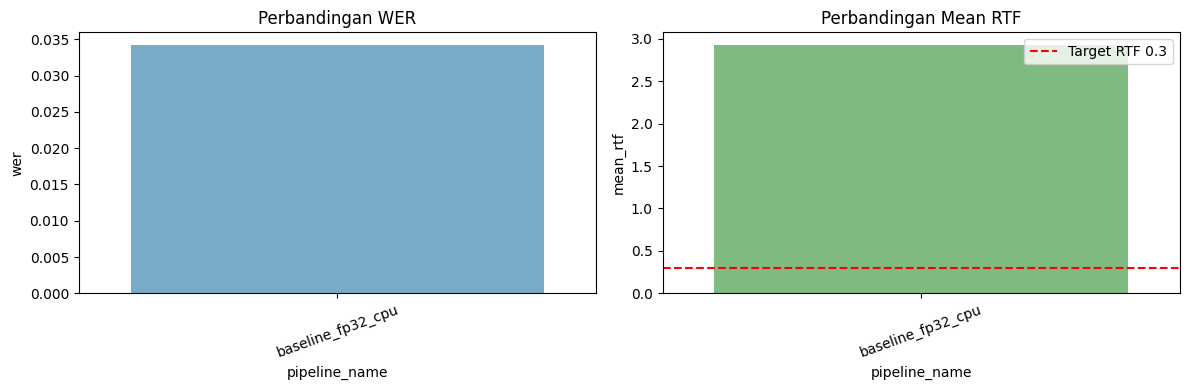

In [19]:
# Sel 17: Visualisasi perbandingan WER dan RTF
if 'summary_df' in globals() and len(summary_df) > 0:
    fig_obj, axes_arr = plt.subplots(1, 2, figsize=(12, 4))
    sns.barplot(data=summary_df, x='pipeline_name', y='wer', ax=axes_arr[0], palette='Blues_r')
    axes_arr[0].set_title('Perbandingan WER')
    axes_arr[0].tick_params(axis='x', rotation=20)
    sns.barplot(data=summary_df, x='pipeline_name', y='mean_rtf', ax=axes_arr[1], palette='Greens_r')
    axes_arr[1].axhline(0.3, color='red', linestyle='--', label='Target RTF 0.3')
    axes_arr[1].set_title('Perbandingan Mean RTF')
    axes_arr[1].tick_params(axis='x', rotation=20)
    axes_arr[1].legend()
    plt.tight_layout()
    plt.show()


In [20]:
# Sel 18: Evaluasi compliance target penelitian dan tabel siap pakai untuk skripsi
model_size_rows = []
for artifact_name in ['distil_small_en_onnx', 'distil_small_en_onnx_int8']:
    folder_path = MODEL_DIR / artifact_name
    size_mb = get_dir_size_mb(folder_path)
    model_size_rows.append({
        'artifact': artifact_name,
        'size_mb': size_mb,
        'meets_target_lt_200mb': bool(size_mb < 200) if not np.isnan(size_mb) else False
    })
model_size_df = pd.DataFrame(model_size_rows)
print(model_size_df)

if 'summary_df' in globals() and len(summary_df) > 0:
    compliance_df = summary_df.copy()
    compliance_df['meets_wer_drift_target'] = compliance_df['wer_delta_vs_baseline_pct_point'] <= 4
    compliance_df['meets_rtf_target'] = compliance_df['mean_rtf'] <= 0.3
    compliance_df['meets_ram_target'] = compliance_df['peak_rss_delta_mb'] <= 1024
    compliance_df['meets_model_size_target'] = compliance_df['model_size_mb'] < 200
    compliance_df['overall_pass'] = (
        compliance_df['meets_wer_drift_target'] &
        compliance_df['meets_rtf_target'] &
        compliance_df['meets_ram_target'] &
        compliance_df['meets_model_size_target']
    )
    thesis_table_df = compliance_df[[
        'pipeline_name',
        'wer',
        'wer_delta_vs_baseline_pct_point',
        'mean_rtf',
        'speedup_vs_baseline_x',
        'peak_rss_delta_mb',
        'model_size_mb',
        'overall_pass'
    ]].copy()
    print(compliance_df)
    print(thesis_table_df)


                    artifact  size_mb  meets_target_lt_200mb
0       distil_small_en_onnx      NaN                  False
1  distil_small_en_onnx_int8      NaN                  False
       pipeline_name       wer  mean_rtf  median_rtf  peak_rss_delta_mb  \
0  baseline_fp32_cpu  0.034268   2.93179    2.664859         205.351562   

   mean_cpu_after_pct  model_size_mb  wer_delta_vs_baseline_pct_point  \
0               13.46            NaN                              0.0   

   speedup_vs_baseline_x  meets_wer_drift_target  meets_rtf_target  \
0                    1.0                    True             False   

   meets_ram_target  meets_model_size_target  overall_pass  
0              True                    False         False  
       pipeline_name       wer  wer_delta_vs_baseline_pct_point  mean_rtf  \
0  baseline_fp32_cpu  0.034268                              0.0   2.93179   

   speedup_vs_baseline_x  peak_rss_delta_mb  model_size_mb  overall_pass  
0                    1.0  

In [21]:
# Sel 19: Simpan seluruh hasil utama ke file CSV untuk analisis skripsi dan paper
summary_path = RESULT_DIR / 'benchmark_summary.csv'
summary_df.to_csv(summary_path, index=False)
print(str(summary_path))

baseline_path = RESULT_DIR / 'baseline_predictions.csv'
baseline_result_df.to_csv(baseline_path, index=False)
print(str(baseline_path))

if 'benchmark_result_df' in globals() and len(benchmark_result_df) > 0:
    benchmark_path = RESULT_DIR / 'onnx_benchmark_predictions.csv'
    benchmark_result_df.to_csv(benchmark_path, index=False)
    print(str(benchmark_path))

if 'compliance_df' in globals():
    compliance_path = RESULT_DIR / 'compliance_summary.csv'
    compliance_df.to_csv(compliance_path, index=False)
    print(str(compliance_path))

if 'thesis_table_df' in globals():
    thesis_table_path = RESULT_DIR / 'thesis_ready_results_table.csv'
    thesis_table_df.to_csv(thesis_table_path, index=False)
    print(str(thesis_table_path))


/content/asr_cpu_artifacts/results/benchmark_summary.csv
/content/asr_cpu_artifacts/results/baseline_predictions.csv
/content/asr_cpu_artifacts/results/compliance_summary.csv
/content/asr_cpu_artifacts/results/thesis_ready_results_table.csv


## Fase 4 - Analisis Pareto dan Integrasi Sistem


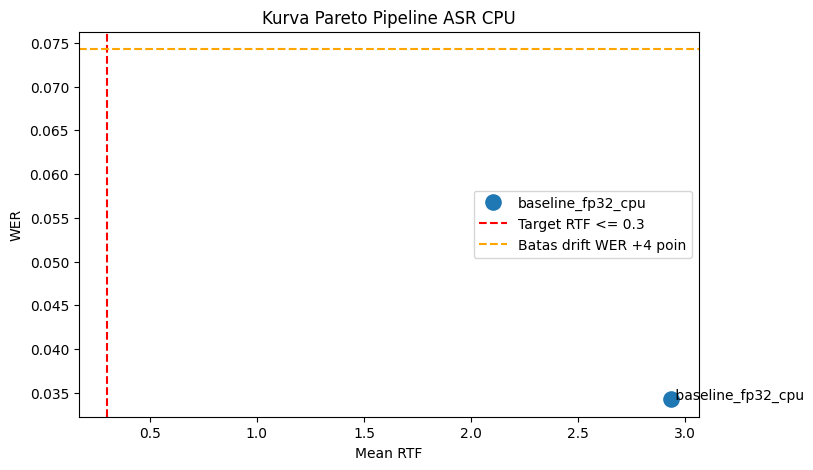

In [22]:
# Sel 20: Plot Pareto WER vs RTF dengan label pipeline dan area target penelitian
if 'summary_df' in globals() and len(summary_df) > 0:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=summary_df, x='mean_rtf', y='wer', hue='pipeline_name', s=170)
    for _, row_obj in summary_df.iterrows():
        plt.text(row_obj['mean_rtf'], row_obj['wer'], ' ' + row_obj['pipeline_name'])
    plt.axvline(0.3, color='red', linestyle='--', label='Target RTF <= 0.3')
    plt.axhline(baseline_wer_value + 0.04, color='orange', linestyle='--', label='Batas drift WER +4 poin')
    plt.title('Kurva Pareto Pipeline ASR CPU')
    plt.xlabel('Mean RTF')
    plt.ylabel('WER')
    plt.legend()
    plt.show()


In [23]:
# Sel 21: Template integrasi AIRA dengan output metadata yang lebih siap dipakai aplikasi
ASR_CONFIG = {
    'pipeline_name': 'onnx_int8_vad',
    'sample_rate': SAMPLE_RATE,
    'language': LANGUAGE,
    'task': TASK,
    'offline_first': True,
    'provider': CPU_PROVIDER,
    'model_id': MODEL_ID
}
print(json.dumps(ASR_CONFIG, indent=2))

def transcribe_for_aira(audio_array, use_vad=True):
    if onnx_pipe is None:
        raise RuntimeError('Pipeline ONNX INT8 belum siap.')
    audio_input = np.asarray(audio_array, dtype=np.float32)
    vad_meta = {'speech_ratio': 1.0, 'num_segments': 1, 'trimmed': False, 'fallback_used': False}
    if use_vad:
        audio_input, vad_meta = apply_silero_vad(audio_input, SAMPLE_RATE)
    if len(audio_input) == 0:
        audio_input = np.asarray(audio_array, dtype=np.float32)
        vad_meta['fallback_used'] = True
    start_time = time.perf_counter()
    result_obj = onnx_pipe(audio_input, generate_kwargs=ONNX_GENERATE_KWARGS)
    infer_seconds = time.perf_counter() - start_time
    return {
        'text': result_obj['text'],
        'vad_meta': vad_meta,
        'audio_seconds_processed': len(audio_input) / SAMPLE_RATE,
        'inference_seconds': infer_seconds,
        'rtf_estimate': compute_rtf(infer_seconds, len(audio_input) / SAMPLE_RATE),
        'config': ASR_CONFIG
    }

def transcribe_audio_file(audio_path, use_vad=True):
    audio_array, loaded_sr = librosa.load(audio_path, sr=SAMPLE_RATE, mono=True)
    result_obj = transcribe_for_aira(audio_array, use_vad=use_vad)
    result_obj['audio_path'] = str(audio_path)
    result_obj['loaded_sample_rate'] = loaded_sr
    return result_obj


{
  "pipeline_name": "onnx_int8_vad",
  "sample_rate": 16000,
  "language": "english",
  "task": "transcribe",
  "offline_first": true,
  "provider": "CPUExecutionProvider",
  "model_id": "distil-whisper/distil-small.en"
}
